In [1]:
!unzip wine+quality.zip

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

In [3]:
# Load red wine dataset
df = pd.read_csv("winequality-red.csv", sep=";")

# Quick overview
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
np.max(df["quality"])

8

In [5]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


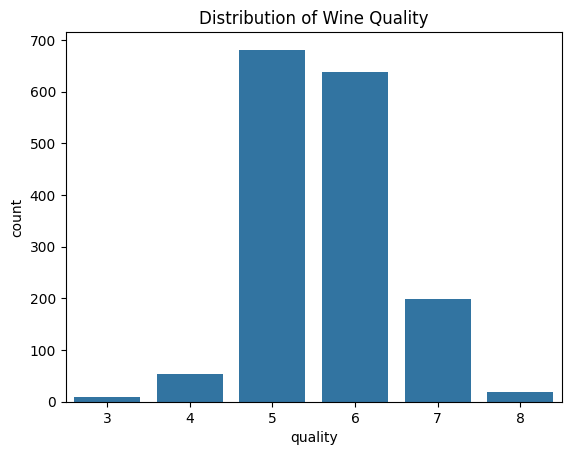

In [6]:
#dataset improportionlity
sns.countplot(x="quality", data=df)
plt.title("Distribution of Wine Quality")
plt.show()

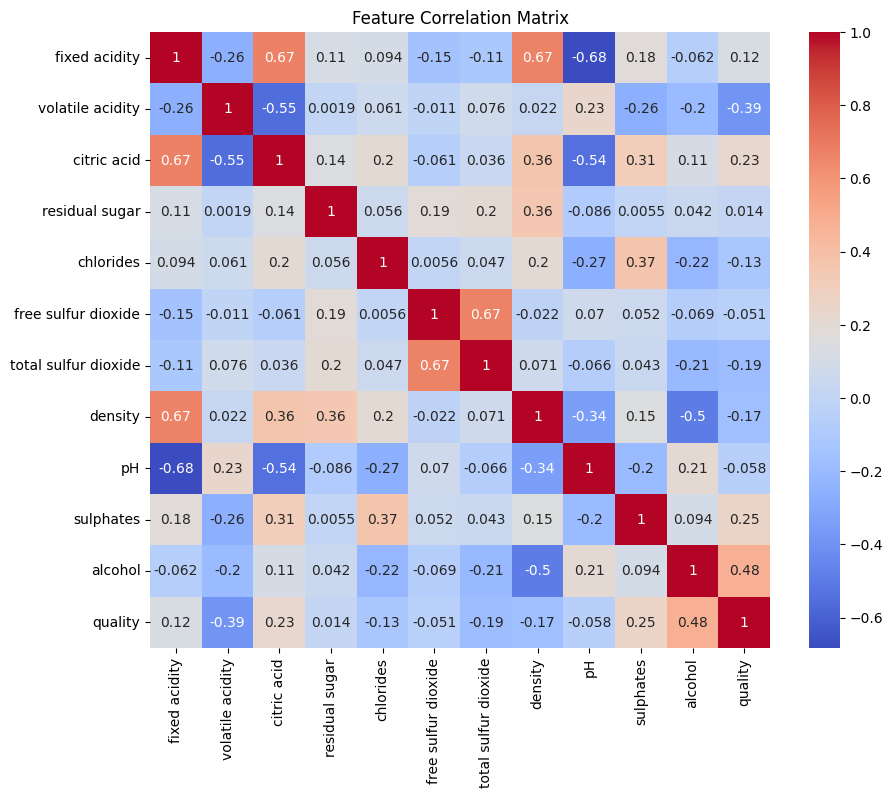

In [7]:
#correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Finalize model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [12]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

RMSE: 0.553
R² Score: 0.532


Feature Importance

In [13]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

                 Feature  Importance
10               alcohol    0.272652
9              sulphates    0.151100
1       volatile acidity    0.108390
6   total sulfur dioxide    0.077636
4              chlorides    0.070043
8                     pH    0.061484
3         residual sugar    0.058068
7                density    0.052488
0          fixed acidity    0.052336
2            citric acid    0.048978
5    free sulfur dioxide    0.046824


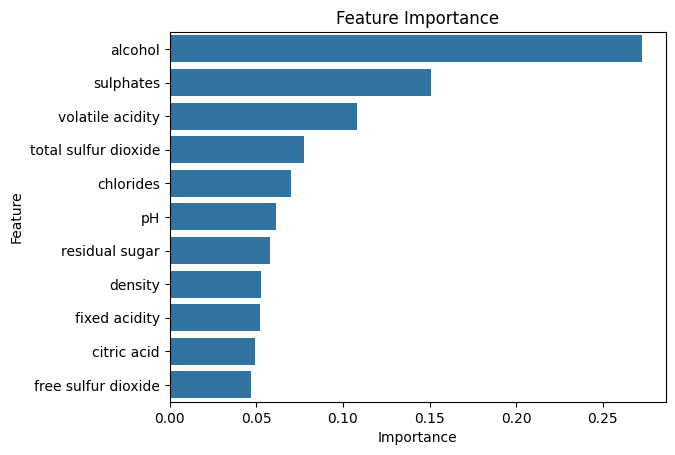

In [14]:
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [15]:
####how should this model be improved in order to make better scoring .

In [16]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Use the numeric quality as target (no need for quality_label)
X = df.drop(["quality"], axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight= "balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.78      0.75       130
           6       0.64      0.71      0.67       132
           7       0.69      0.52      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.34      0.34      0.34       320
weighted avg       0.65      0.68      0.66       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist, n_iter=30, cv=5,
    scoring="f1_weighted", random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)

Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [19]:
from xgboost import XGBClassifier


# Remap quality scores to be zero-indexed for XGBoost
y_train_remapped = y_train - 3
y_test_remapped = y_test - 3

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    # use_label_encoder=False, # Deprecated in recent XGBoost versions
    eval_metric="mlogloss", # For multi-class classification
    random_state=42
)
xgb.fit(X_train, y_train_remapped) # Use remapped y_train
print(classification_report(y_test_remapped, xgb.predict(X_test))) # Use remapped y_test

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        10
           2       0.75      0.77      0.76       130
           3       0.64      0.73      0.68       132
           4       0.66      0.55      0.60        42
           5       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.34      0.34      0.34       320
weighted avg       0.66      0.68      0.67       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
#balancing teh classes using Smote and again fitting the xgboost
from imblearn.over_sampling import SMOTE

# Before SMOTE
print("Original training set target distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# After SMOTE
print("\nResampled training set target distribution:")
print(y_train_res.value_counts())

Original training set target distribution:
quality
5    551
6    506
7    157
4     43
8     13
3      9
Name: count, dtype: int64

Resampled training set target distribution:
quality
6    551
5    551
4    551
7    551
8    551
3    551
Name: count, dtype: int64


In [21]:
# Remap the resampled y_train to be zero-indexed for XGBoost
y_train_res_remapped = y_train_res - 3

xgb.fit(X_train_res, y_train_res_remapped) # Use resampled and remapped y_train
print(classification_report(y_test_remapped, xgb.predict(X_test))) # Use remapped y_test

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.18      0.30      0.22        10
           2       0.78      0.72      0.75       130
           3       0.72      0.70      0.71       132
           4       0.58      0.62      0.60        42
           5       0.12      0.20      0.15         5

    accuracy                           0.68       320
   macro avg       0.40      0.42      0.41       320
weighted avg       0.70      0.68      0.69       320



### Hyperparameter Tuning for XGBoost

In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9, 11],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4]
}

# Initialize XGBClassifier (using the remapped target for evaluation)
# The 'eval_metric' here is for internal xgboost evaluation, we'll use 'f1_weighted' for RandomizedSearchCV
xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Setup RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50, # Number of parameter settings that are sampled. Increase for a more exhaustive search.
    scoring='f1_weighted', # Use f1_weighted to handle class imbalance
    cv=5, # 5-fold cross-validation
    verbose=1, # Print progress messages
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the SMOTE-resampled training data
random_search_xgb.fit(X_train_res, y_train_res_remapped)

# Print the best parameters and the best score
print("Best parameters found: ", random_search_xgb.best_params_)
print("Best f1_weighted score found: ", random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 11, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best f1_weighted score found:  0.8738393299944166


After finding the best parameters, we will train a new XGBoost model with these parameters and evaluate its performance.

In [23]:
# Train a new XGBoost model with the best parameters
best_xgb_model = XGBClassifier(
    subsample=0.8,
    n_estimators=700,
    max_depth=11,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric='mlogloss'
)

best_xgb_model.fit(X_train_res, y_train_res_remapped)

# Make predictions on the test set
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model with Tuned Hyperparameters (after SMOTE):")
print(classification_report(y_test_remapped, y_pred_tuned_xgb))

XGBoost Model with Tuned Hyperparameters (after SMOTE):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.16      0.30      0.21        10
           2       0.78      0.72      0.75       130
           3       0.70      0.69      0.69       132
           4       0.58      0.60      0.59        42
           5       0.14      0.20      0.17         5

    accuracy                           0.67       320
   macro avg       0.39      0.42      0.40       320
weighted avg       0.69      0.67      0.68       320



In [24]:
#LogistRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 10000)
model.fit(X_train_res, y_train_res_remapped)

LogisticRegression(max_iter=10000)

In [25]:
from sklearn.metrics import accuracy_score
y_pred =model.predict(X_test_scaled)
accuracy_score(y_pred, y_test_remapped)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.3625

In [26]:
#KNN classifier
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_res, y_train_res_remapped)


KNeighborsClassifier()

In [27]:

y_pred =model_knn.predict(X_test_scaled)
accuracy_score(y_pred, y_test_remapped)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.03125

In [28]:
#SVC classifier
from sklearn.svm import SVC
model_svc = SVC()
model_svc.fit(X_train_res, y_train_res_remapped)

SVC()

In [29]:
y_pred =model_svc.predict(X_test_scaled)
accuracy_score(y_pred, y_test_remapped)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.003125

In [30]:
# What does a high-quality wine look like?
high_quality = df[df["quality"] >= 7]
low_quality = df[df["quality"] <= 5]

comparison = pd.DataFrame({
    "High Quality (7-8)": high_quality.mean(),
    "Low Quality (3-5)": low_quality.mean(),
    "Difference": high_quality.mean() - low_quality.mean()
})
print(comparison)

                      High Quality (7-8)  Low Quality (3-5)  Difference
fixed acidity                   8.847005           8.142204    0.704800
volatile acidity                0.405530           0.589503   -0.183973
citric acid                     0.376498           0.237755    0.138742
residual sugar                  2.708756           2.542070    0.166686
chlorides                       0.075912           0.092989   -0.017077
free sulfur dioxide            13.981567          16.567204   -2.585637
total sulfur dioxide           34.889401          54.645161  -19.755760
density                         0.996030           0.997068   -0.001038
pH                              3.288802           3.311653   -0.022851
sulphates                       0.743456           0.618535    0.124921
alcohol                        11.518049           9.926478    1.591571
quality                         7.082949           4.901882    2.181068


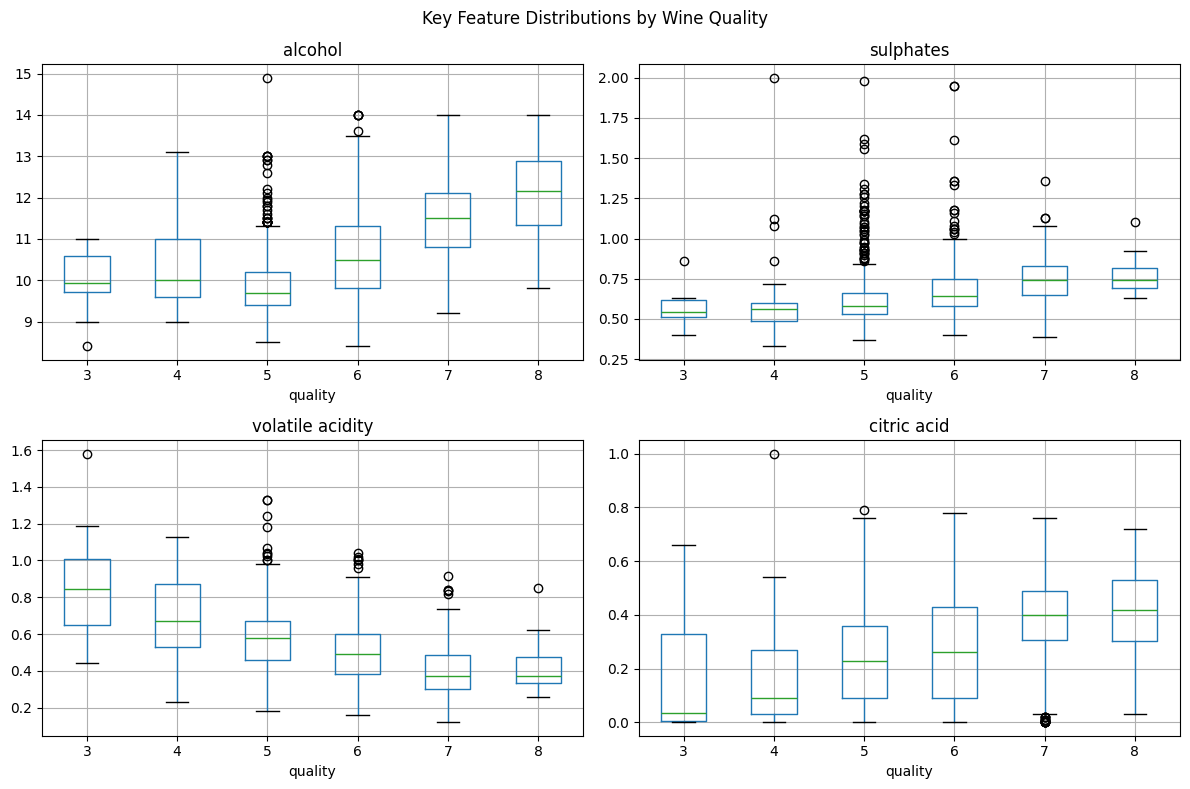

In [31]:
import matplotlib.pyplot as plt

# Box plots: feature distributions by quality
features_of_interest = ["alcohol", "sulphates", "volatile acidity", "citric acid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features_of_interest):
    df.boxplot(column=feature, by="quality", ax=ax)
    ax.set_title(feature)
plt.suptitle("Key Feature Distributions by Wine Quality")
plt.tight_layout()
plt.show()

In [33]:
print(X_test_scaled[0])

[-3.61859850e-01  1.64286407e-01 -9.85152962e-01 -3.86510130e-02
  5.18158057e-01 -1.81975648e-01 -1.99566462e-02  1.75731759e-01
 -4.65392578e-01 -1.34389336e-04 -7.77452782e-01]


In [35]:
test_point = [8.847005, 0.405530, 0.376498, 2.708756, 0.075912, 13.981567, 34.889401, 0.996030, 3.288802, 0.743456, 11.518049]
test_point_scaled = scaler.transform([test_point])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
#svc prediction - low accuracy
model_svc.predict(test_point_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [37]:
#knn prediction - low accuracy
model_knn.predict(test_point_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [38]:
#xgboost_best_parameter prediction - high accuracy
best_xgb_model.predict(test_point_scaled)

array([3])

In [40]:
#xgb base prediction - high accuracy
xgb.predict(test_point_scaled)

array([3])

In [41]:
#randomforest_gridSearchCV
search.predict(test_point_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([6])

In [42]:
#normal randomforest
model.predict(test_point_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

So on the best Data point of the analysis on which the model should give the high quality - only RandomisedSearchCV with randomforest has given the best output

Lets go through the NN models - how will they perform on it

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu, sigmoid, softmax
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [72]:
!pip install scikeras

In [52]:
y_train_res_remapped.isnull().sum()

np.int64(0)

In [62]:
X_train_res_scaled = scaler.transform(X_train_res)

In [66]:
#build the model
model = Sequential(
    [
        Dense(128, activation = "relu", input_shape=(X_train_res.shape[1],)),
        Dense(64, activation = "relu"),
        Dense(6, activation = "softmax"), # Changed to 6 units for 6 classes

    ], name = "model"
)
model.compile(optimizer = Adam(), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) # Changed loss function
model.fit(X_train_res_scaled, y_train_res_remapped, epochs=35) # Added X_train_res as input features

Epoch 1/35


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5024 - loss: 1.2633
Epoch 2/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6512 - loss: 0.9247
Epoch 3/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6927 - loss: 0.8162
Epoch 4/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7193 - loss: 0.7468
Epoch 5/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7374 - loss: 0.6920
Epoch 6/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7589 - loss: 0.6508
Epoch 7/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7743 - loss: 0.6105
Epoch 8/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7840 - loss: 0.5851
Epoch 9/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7840 - loss: 0.5626
Epoch 10/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7989 - loss: 0.5344
Epoch 11/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8061 - loss: 0.5232
Epoch 12/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

In [63]:
#build the model
model = Sequential(
    [
        Dense(128, activation = "relu", input_shape=(X_train_res_scaled.shape[1],)),
        Dense(64, activation = "relu"),
        Dense(6, activation = "softmax"), # Changed to 6 units for 6 classes

    ], name = "model"
)
model.compile(optimizer = Adam(), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) # Changed loss function
model.fit(X_train_res_scaled, y_train_res_remapped, epochs=35) # Use the correctly scaled training data

Epoch 1/35


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5236 - loss: 1.2629
Epoch 2/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6488 - loss: 0.9226
Epoch 3/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6999 - loss: 0.8094
Epoch 4/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7290 - loss: 0.7393
Epoch 5/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7477 - loss: 0.6846
Epoch 6/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7659 - loss: 0.6421
Epoch 7/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7777 - loss: 0.6044
Epoch 8/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7892 - loss: 0.5720
Epoch 9/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7955 - loss: 0.5484
Epoch 10/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.5265
Epoch 11/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.5028
Epoch 12/35
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [64]:
accuracy_score(model.predict(X_test_scaled).argmax(axis=1), y_test_remapped)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  


0.546875

In [65]:
from sklearn.metrics import f1_score

y_pred_nn = model.predict(X_test_scaled).argmax(axis=1)
f1 = f1_score(y_test_remapped, y_pred_nn, average='weighted')
print(f"Neural Network F1-Score (weighted): {f1:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Neural Network F1-Score (weighted): 0.557


In [67]:
from sklearn.metrics import classification_report

y_pred_nn_classes = model.predict(X_test_scaled).argmax(axis=1)
print("Neural Network Classification Report:")
print(classification_report(y_test_remapped, y_pred_nn_classes))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.10      0.20      0.13        10
           2       0.66      0.73      0.69       130
           3       0.64      0.44      0.52       132
           4       0.46      0.60      0.52        42
           5       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.31      0.33      0.31       320
weighted avg       0.60      0.56      0.57       320



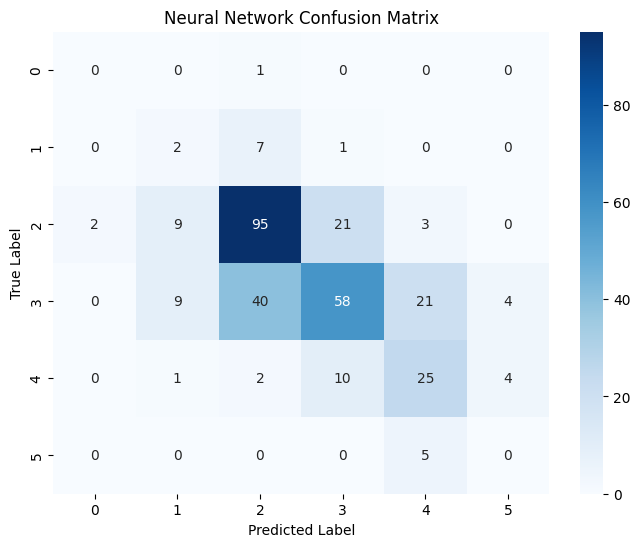

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Neural Network Confusion Matrix
cm_nn = confusion_matrix(y_test_remapped, y_pred_nn_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues')
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Hyperparameter Tuning for Neural Network

In [74]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.4.2
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Define a function to create the Keras model (this will be passed to KerasClassifier)
def create_nn_model(learning_rate=0.001, num_hidden_layers=1, neurons_per_layer=64, activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Dense(neurons_per_layer, activation=activation, input_shape=(X_train_res_scaled.shape[1],)))
    for _ in range(num_hidden_layers - 1):
        model.add(Dense(neurons_per_layer, activation=activation))
    model.add(Dense(6, activation='softmax')) # 6 output classes

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate) # Default to Adam

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Create a KerasClassifier wrapper for our model
keras_nn_model = KerasClassifier(model=create_nn_model, verbose=0, random_state=42)

# Define the hyperparameter space to search
param_dist_nn = {
    'model__learning_rate': [0.001, 0.005, 0.01, 0.05],
    'model__num_hidden_layers': [1, 2, 3],
    'model__neurons_per_layer': [32, 64, 128, 256],
    'model__activation': ['relu', 'tanh'],
    'model__optimizer': ['adam', 'sgd', 'rmsprop'],
    'batch_size': [32, 64, 128],
    'epochs': [20, 30, 50, 70]
}

# Setup RandomizedSearchCV
random_search_nn = RandomizedSearchCV(
    estimator=keras_nn_model,
    param_distributions=param_dist_nn,
    n_iter=30, # Number of parameter settings that are sampled. Increase for a more exhaustive search.
    cv=3, # Using 3-fold cross-validation to speed up the process
    scoring='f1_weighted', # Use f1_weighted to handle class imbalance
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the SMOTE-resampled and scaled training data
# Note: KerasClassifier expects X_train_res_scaled not X_train_res
random_search_nn.fit(X_train_res_scaled, y_train_res_remapped)

# Print the best parameters and the best score
print("Best parameters found for NN: ", random_search_nn.best_params_)
print("Best f1_weighted score found for NN: ", random_search_nn.best_score_)

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 114.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


AttributeError: 'super' object has no attribute '__sklearn_tags__'

After tuning, we will evaluate the best Neural Network model on the test set.

In [71]:
# Get the best NN model from the random search
best_nn_model = random_search_nn.best_estimator_

# Make predictions on the scaled test set
y_pred_tuned_nn = best_nn_model.predict(X_test_scaled)

# Evaluate the model
print("Neural Network Model with Tuned Hyperparameters (after SMOTE):")
print(classification_report(y_test_remapped, y_pred_tuned_nn))

# Neural Network Confusion Matrix (Tuned)
cm_tuned_nn = confusion_matrix(y_test_remapped, y_pred_tuned_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_nn, annot=True, fmt='d', cmap='Blues')
plt.title('Neural Network (Tuned & SMOTE) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

NameError: name 'random_search_nn' is not defined

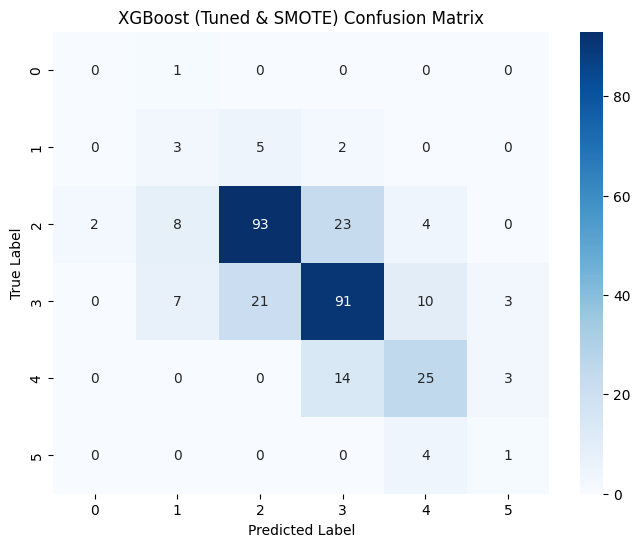

In [69]:
# XGBoost Confusion Matrix (Tuned & Post-SMOTE)
cm_xgb = confusion_matrix(y_test_remapped, y_pred_tuned_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost (Tuned & SMOTE) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()